In [19]:
import pandas as pd
import matplotlib.pyplot as plt

loans = pd.read_csv("../data/clean/loans_clean.csv")

In [20]:
loans["credit_score_category"] = pd.cut(
    loans["credit_score"],
    bins=[300,580,670,740,800,850],
    labels=["Poor","Fair","Good","Very Good","Excellent"],
    include_lowest=True
)

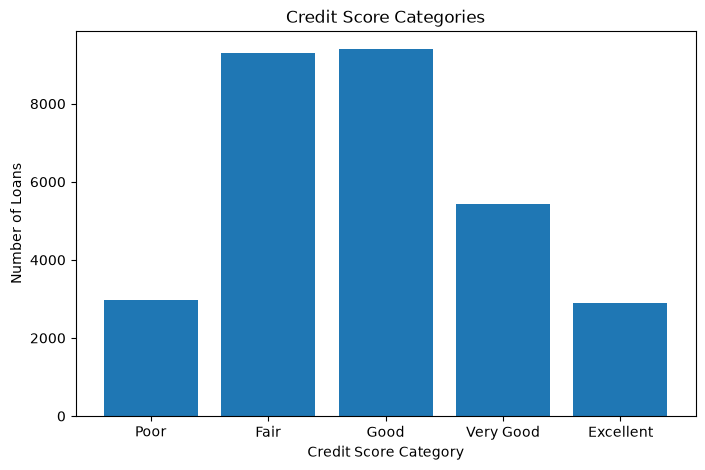

In [21]:
credit = loans["credit_score_category"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(credit.index.astype(str), credit.values)

plt.title("Credit Score Categories")
plt.xlabel("Credit Score Category")
plt.ylabel("Number of Loans")

plt.show()

Fair & Good tiers dominate: The vast majority of borrowers fall into the Fair and Good categories, each accounting for over 9,000 loans.

Moderate higher-tier presence: Very Good credit scores make up a solid middle group (~5,400 loans), while Poor and Excellent categories share the lower end at around 3,000 loans each.

In [22]:
loans["loan_size"] = pd.cut(
    loans["loan_amount"],
    bins=[0,50000,150000,300000,500000],
    labels=["Small","Medium","Large","Very Large"])

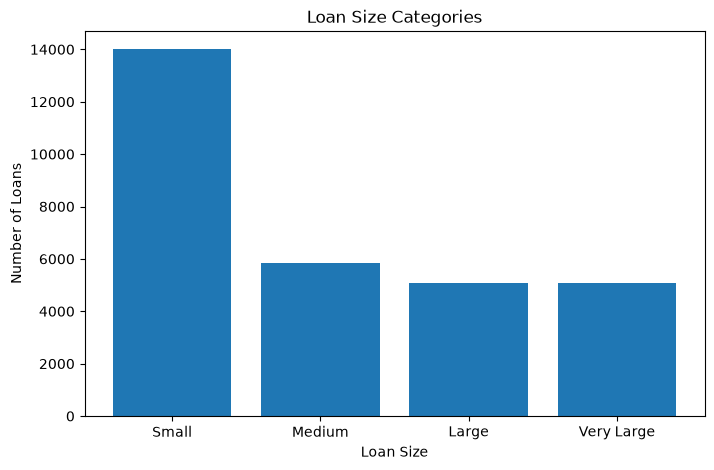

In [23]:
loan_size = loans["loan_size"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(loan_size.index.astype(str), loan_size.values)

plt.title("Loan Size Categories")
plt.xlabel("Loan Size")
plt.ylabel("Number of Loans")

plt.show()

Small loans heavily dominate: Small loans make up the vast majority of the portfolio, reaching 14,000 loans—more than double any other category.

Even spread across larger sizes: Medium (~5,800), Large (~5,100), and Very Large (~5,100) loans account for smaller, remarkably equal shares of the remaining distribution.

In [24]:
loans["remaining_balance_pct"] = (
    loans["remaining_balance"] /loans["loan_amount"]) * 100

loans["remaining_balance_pct"] = loans["remaining_balance_pct"].round(1)

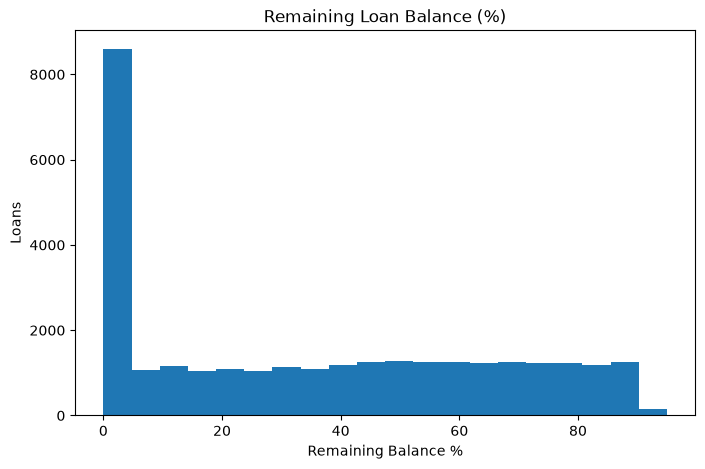

In [25]:
plt.figure(figsize=(8,5))
plt.hist(loans["remaining_balance_pct"], bins=20)

plt.title("Remaining Loan Balance (%)")
plt.xlabel("Remaining Balance %")
plt.ylabel("Loans")

plt.show()

Massive cluster near 0% balance: Over 8,500 loans sit right at or near 0% remaining balance, representing fully repaid or closed accounts.

Uniform distribution for active loans: Across the 10% to 90% range, remaining balances are spread exceptionally evenly, holding a steady baseline of around 1,000 to 1,200 loans per bin.

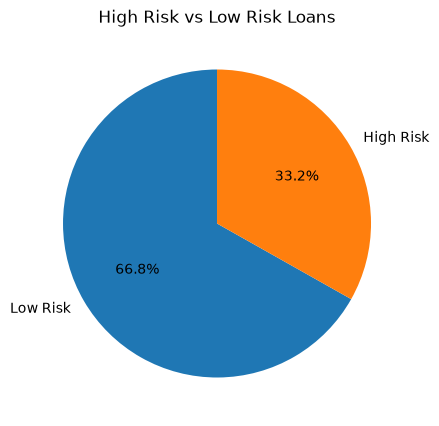

In [26]:
loans["high_risk"] = ((loans["credit_score"] < 650) |(loans["default_flag"] == "Yes"))

risk = loans["high_risk"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(risk,labels=["Low Risk","High Risk"],autopct="%1.1f%%",startangle=90)

plt.title("High Risk vs Low Risk Loans")

plt.show()

Majority Low Risk: Two-thirds of the loan portfolio (66.8%) is categorized as Low Risk.

Significant High-Risk exposure: A substantial 33.2% (roughly 1 in 3 loans) is flagged as High Risk, indicating a sizable portion of the portfolio requires closer monitoring or tighter underwriting standards.

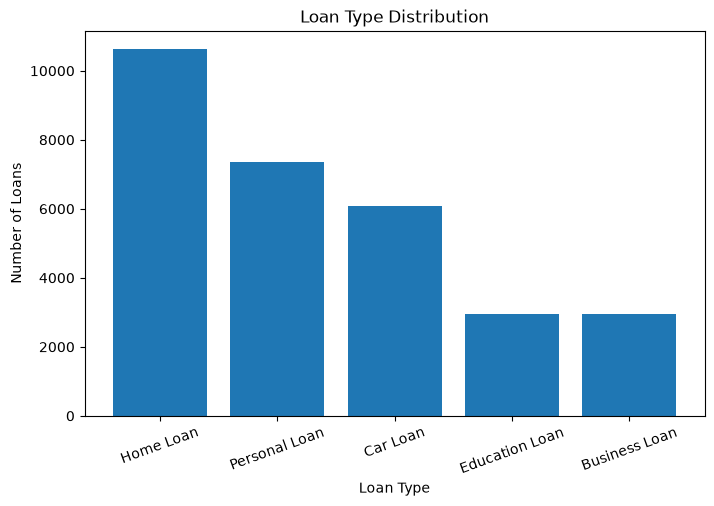

In [27]:
loan_type = loans["loan_type"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(loan_type.index, loan_type.values)

plt.title("Loan Type Distribution")
plt.xlabel("Loan Type")
plt.ylabel("Number of Loans")

plt.xticks(rotation=20)

plt.show()

Home Loans lead product volume: Home Loans are the most common loan type by far, topping the distribution at over 10,000 loans.

Tiered product demand: Consumer loans follow next with Personal Loans (~7,300) and Car Loans (~6,100), while Education and Business Loans tie for the smallest share at around 3,000 loans each.

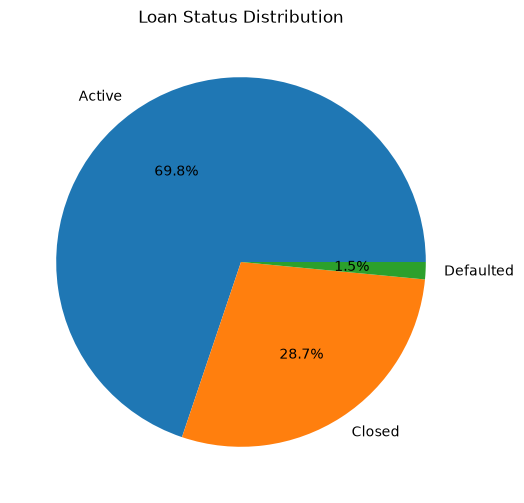

In [28]:
status = loans["loan_status"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(status,labels=status.index,autopct="%1.1f%%")

plt.title("Loan Status Distribution")

plt.show()

Active portfolio dominance: Active loans make up the vast majority at 69.8%, showing that most accounts are currently ongoing.

Low loss rate: Fully paid Closed loans account for 28.7%, while explicitly Defaulted loans represent a very small 1.5%.

Imbalance note: Because defaulted loans are so rare, any predictive modeling on this dataset will need special techniques (like reweighting or SMOTE) to catch default risk effectively.

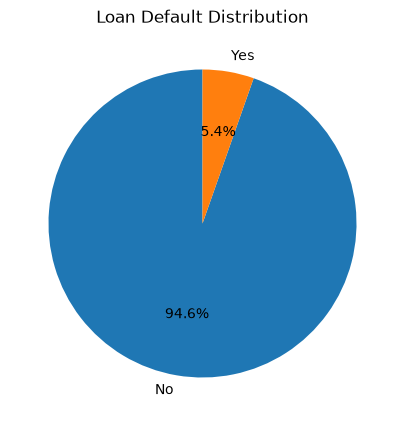

In [29]:
default = loans["default_flag"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(default,labels=default.index,autopct="%1.1f%%",startangle=90)

plt.title("Loan Default Distribution")

plt.show()

Non-Defaulters (No): Make up the vast majority of the dataset at 94.6%.

Defaulters (Yes): Represent a small minority at 5.4%.

Severe Class Imbalance: The data is heavily imbalanced (~17.5 to 1 ratio), which is standard for loan default datasets and means any predictive model will need strategies like resampling (SMOTE/undersampling) or custom class weighting to effectively catch default risks.

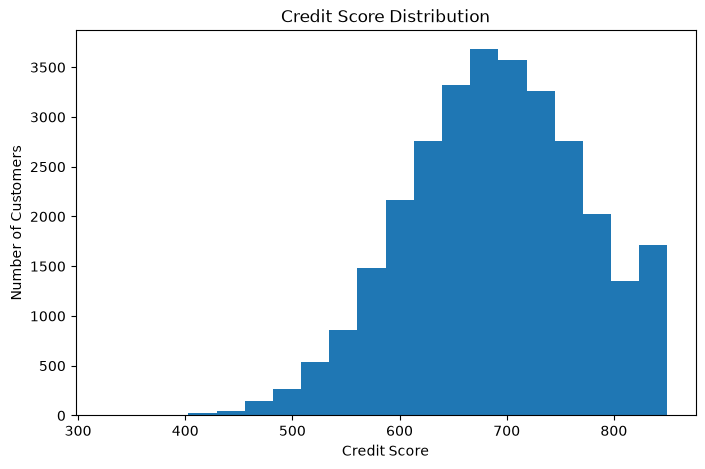

In [30]:
plt.figure(figsize=(8,5))
plt.hist(loans["credit_score"], bins=20)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

Peak concentration: The majority of customers have credit scores centered around 660 to 720, reaching a peak of roughly 3,600 to 3,700 customers in the 670–690 range.

Left-skewed distribution: The data trails off significantly toward lower credit scores (below 550), while maintaining a high concentration in the fair-to-good credit score range.

Upper boundary uptick: There is a noticeable bump at the upper edge (820 to 850), likely due to score capping at 850.

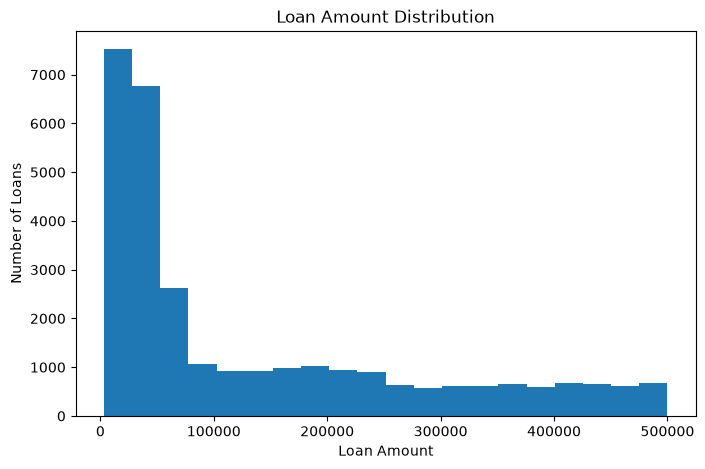

In [31]:
plt.figure(figsize=(8,5))
plt.hist(loans["loan_amount"], bins=20)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Loans")

plt.show()

Heavily concentrated at lower amounts: The vast majority of loans are clustered under $100,000, with a sharp peak occurring between $10,000 and $50,000 (exceeding 7,500 loans).

Strong right-skewed distribution: Beyond $100,000, the volume drops off significantly and forms a long, flat tail that extends across higher loan amounts up to $500,000.

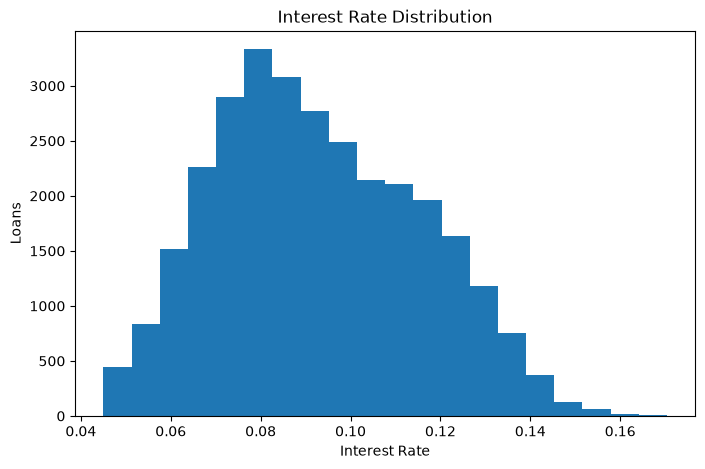

In [32]:
plt.figure(figsize=(8,5))
plt.hist(loans["interest_rate"], bins=20)

plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate")
plt.ylabel("Loans")

plt.show()

Peak concentration: The majority of loans feature interest rates clustered between 7.5% and 8.5% (0.075 to 0.085), peaking at over 3,300 loans.

Slight right skew: The distribution is unimodal and roughly bell-shaped, but stretches further to the right—sloping down gradually toward higher interest rates up to 16%–17% (0.16 to 0.17).

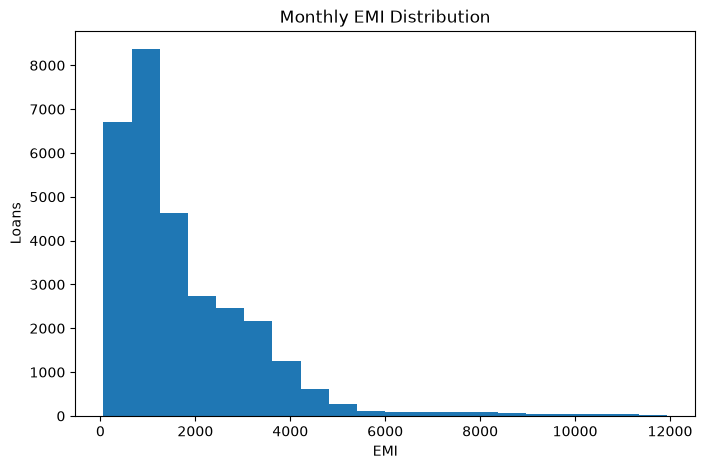

In [33]:
plt.figure(figsize=(8,5))
plt.hist(loans["emi"], bins=20)

plt.title("Monthly EMI Distribution")
plt.xlabel("EMI")
plt.ylabel("Loans")

plt.show()

Concentrated in lower ranges: Most loans fall into lower EMI amounts, with the peak frequency occurring between $500 and $1,500.

Right-skewed distribution: The volume drops off sharply past $4,000, leaving a thin long tail of high EMI values extending up to $12,000.

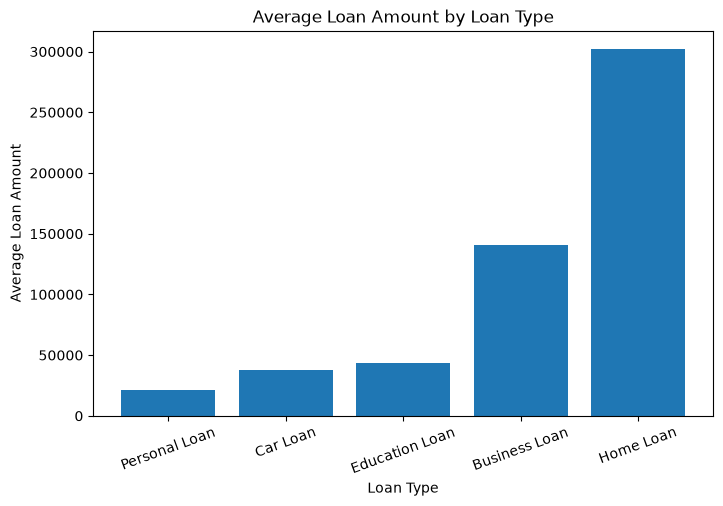

In [34]:
avg_loan = loans.groupby("loan_type")["loan_amount"].mean().sort_values()

plt.figure(figsize=(8,5))
plt.bar(avg_loan.index, avg_loan.values)

plt.title("Average Loan Amount by Loan Type")
plt.xlabel("Loan Type")
plt.ylabel("Average Loan Amount")

plt.xticks(rotation=20)

plt.show()

Home Loans heavily dominate: Home Loans carry the largest average balance by far, reaching over $300,000.

Business Loans sit in the middle tier: Business Loans take second place at around $140,000, while Personal, Car, and Education loans remain significantly smaller (under $50,000 each).

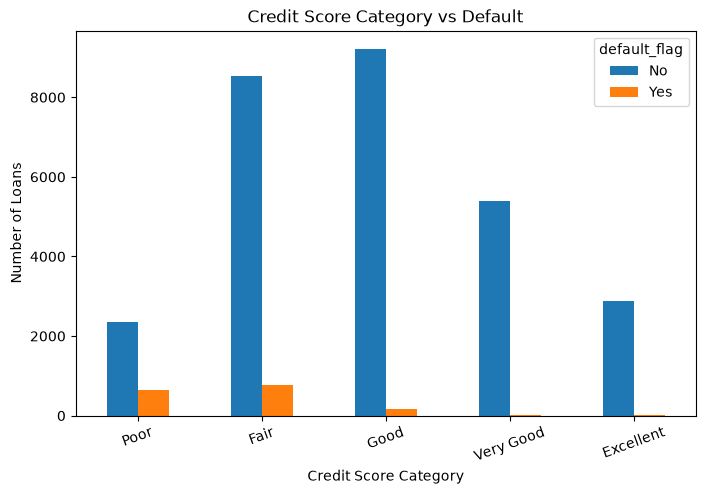

In [35]:
cross = pd.crosstab(
    loans["credit_score_category"],
    loans["default_flag"]
)

cross.plot(kind="bar", figsize=(8,5))

plt.title("Credit Score Category vs Default")
plt.xlabel("Credit Score Category")
plt.ylabel("Number of Loans")

plt.xticks(rotation=20)

plt.show()

Better credit scores mean almost zero defaults: Borrowers with Good, Very Good, or Excellent credit scores pay back their loans almost every single time.

Defaults happen in lower score tiers: Nearly all unpaid loans (the orange bars) come from borrowers with Poor or Fair credit scores.